# HF Korean Project: KLUE-STS 두 문장 관계 판별

기존 GLUE MRPC 실습 흐름을 KLUE-STS 데이터셋과 `klue/bert-base` 모델에 맞게 바꾼 노트북입니다. 커스텀 데이터셋 생성 코드는 제외하고, KLUE-STS의 `binary-label`을 사용해 두 문장이 의미적으로 유사한지 분류합니다.

## 라이브러리 의존성

uv 환경에 이미 라이브러리가 설치되어 있다는 전제로 작성했습니다. 필요한 패키지는 `transformers`, `datasets`, `accelerate`, `torch`, `numpy`이며, Mecab 실험을 켤 경우 `mecab` 모듈이 필요합니다.

# (1) Hugging Face 데이터셋 불러오기

KLUE-STS 데이터셋을 Hugging Face `datasets`에서 불러옵니다. 데이터셋은 `train`과 `validation` split으로 제공되며, 각 샘플에는 두 문장과 STS 점수/이진 라벨이 들어 있습니다.

In [15]:
import datasets
from datasets import load_dataset

klue_sts_dataset = load_dataset("klue", "sts")
print(klue_sts_dataset)
print(klue_sts_dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['guid', 'source', 'sentence1', 'sentence2', 'labels'],
        num_rows: 11668
    })
    validation: Dataset({
        features: ['guid', 'source', 'sentence1', 'sentence2', 'labels'],
        num_rows: 519
    })
})
{'guid': 'klue-sts-v1_train_00000', 'source': 'airbnb-rtt', 'sentence1': '숙소 위치는 찾기 쉽고 일반적인 한국의 반지하 숙소입니다.', 'sentence2': '숙박시설의 위치는 쉽게 찾을 수 있고 한국의 대표적인 반지하 숙박시설입니다.', 'labels': {'label': 3.7, 'real-label': 3.714285714285714, 'binary-label': 1}}


`train` split의 컬럼 구성을 확인합니다. 이후 전처리에서 `sentence1`, `sentence2`, `labels['binary-label']`을 사용합니다.

In [16]:
train = klue_sts_dataset["train"]
cols = train.column_names
cols

['guid', 'source', 'sentence1', 'sentence2', 'labels']

실제 샘플 몇 개를 출력해 문장 쌍과 라벨 구조를 확인합니다. `labels` 안의 `binary-label`이 이 프로젝트의 분류 정답입니다.

In [17]:
for i in range(3):
    for col in cols:
        print(col, ":", train[col][i])
    print()

guid : klue-sts-v1_train_00000
source : airbnb-rtt
sentence1 : 숙소 위치는 찾기 쉽고 일반적인 한국의 반지하 숙소입니다.
sentence2 : 숙박시설의 위치는 쉽게 찾을 수 있고 한국의 대표적인 반지하 숙박시설입니다.
labels : {'label': 3.7, 'real-label': 3.714285714285714, 'binary-label': 1}

guid : klue-sts-v1_train_00001
source : policy-sampled
sentence1 : 위반행위 조사 등을 거부·방해·기피한 자는 500만원 이하 과태료 부과 대상이다.
sentence2 : 시민들 스스로 자발적인 예방 노력을 한 것은 아산 뿐만이 아니었다.
labels : {'label': 0.0, 'real-label': 0.0, 'binary-label': 0}

guid : klue-sts-v1_train_00002
source : paraKQC-sampled
sentence1 : 회사가 보낸 메일은 이 지메일이 아니라 다른 지메일 계정으로 전달해줘.
sentence2 : 사람들이 주로 네이버 메일을 쓰는 이유를 알려줘
labels : {'label': 0.3, 'real-label': 0.3333333333333333, 'binary-label': 0}



### 문자열 길이 분포도 시각화

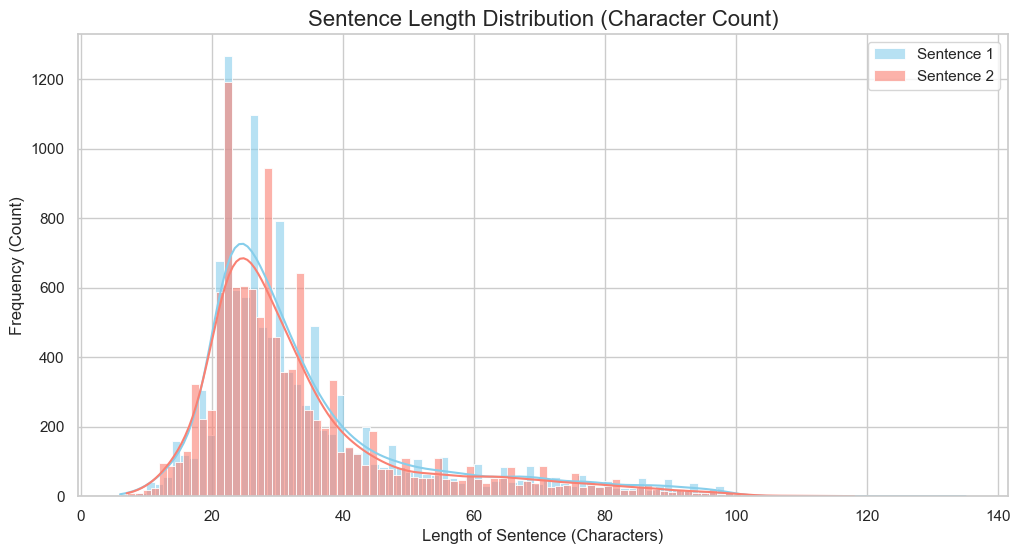

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 각 문장의 길이(글자 수)를 리스트로 추출합니다.
# train은 Hugging Face Dataset 객체라고 가정합니다.
len_sent1 = [len(str(text)) for text in train['sentence1']]
len_sent2 = [len(str(text)) for text in train['sentence2']]

# 2. 그래프 크기 및 스타일 설정
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid") # 깔끔한 배경 설정 (선택사항)

# 3. 히스토그램 그리기 (kde=True를 넣으면 부드러운 확률 밀도 곡선도 같이 그려집니다)
sns.histplot(len_sent1, color='skyblue', label='Sentence 1', kde=True, alpha=0.6)
sns.histplot(len_sent2, color='salmon', label='Sentence 2', kde=True, alpha=0.6)

# 4. 그래프 제목 및 축 이름 설정
plt.title('Sentence Length Distribution (Character Count)', fontsize=16)
plt.xlabel('Length of Sentence (Characters)', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)
plt.legend()

# 5. 화면에 출력
plt.show()

# (2) KLUE-STS 라벨 구성 및 train/evaluation/test 분리

KLUE-STS의 원래 `labels` 컬럼은 점수와 이진 라벨을 함께 담은 딕셔너리입니다. `Trainer`가 바로 사용할 수 있도록 `binary-label`을 별도 `label` 컬럼으로 꺼내고, 원본 `train` 일부를 학습 중 검증용으로 분리합니다. KLUE의 공개 `validation` split은 최종 평가용 test처럼 남겨 둡니다.

In [19]:
from datasets import ClassLabel, DatasetDict

label_feature = ClassLabel(names=["negative", "positive"])


def extract_binary_label(example):
    return {"label": int(example["labels"]["binary-label"])}


klue_sts_labeled = klue_sts_dataset.map(extract_binary_label)
klue_sts_labeled = klue_sts_labeled.cast_column("label", label_feature)

train_eval_split = klue_sts_labeled["train"].train_test_split(
    test_size=0.1,
    seed=42,
    stratify_by_column="label",
)

hf_dataset = DatasetDict(
    {
        "train": train_eval_split["train"],
        "validation": train_eval_split["test"],     # train 데이터셋에서 추출한 test데이터를 validation 데이터셋으로 사용 (모의고사)
        "test": klue_sts_labeled["validation"],     # validation 데이터셋을 test 데이터셋으로 사용 (수능)
    }
)

print(hf_dataset)

DatasetDict({
    train: Dataset({
        features: ['guid', 'source', 'sentence1', 'sentence2', 'labels', 'label'],
        num_rows: 10501
    })
    validation: Dataset({
        features: ['guid', 'source', 'sentence1', 'sentence2', 'labels', 'label'],
        num_rows: 1167
    })
    test: Dataset({
        features: ['guid', 'source', 'sentence1', 'sentence2', 'labels', 'label'],
        num_rows: 519
    })
})


분리된 각 split의 크기와 라벨 비율을 확인합니다. 학습/검증 split은 stratify를 적용해 positive/negative 비율이 크게 흔들리지 않도록 했습니다.

In [20]:
def label_distribution(dataset):
    labels = list(dataset["label"])
    total = len(labels)
    return {
        label_feature.int2str(label_id): {
            "count": labels.count(label_id),
            "ratio": round(labels.count(label_id) / total, 4),
        }
        for label_id in range(label_feature.num_classes)
    }


for split_name, split_dataset in hf_dataset.items():
    print(split_name, len(split_dataset), label_distribution(split_dataset))

train 10501 {'negative': {'count': 5459, 'ratio': 0.5199}, 'positive': {'count': 5042, 'ratio': 0.4801}}
validation 1167 {'negative': {'count': 607, 'ratio': 0.5201}, 'positive': {'count': 560, 'ratio': 0.4799}}
test 519 {'negative': {'count': 299, 'ratio': 0.5761}, 'positive': {'count': 220, 'ratio': 0.4239}}


# 2. 토크나이저와 모델

# 2-(1) Hugging Face Auto Classes를 이용하는 방법

한국어 문장 쌍 분류에는 `klue/bert-base`를 사용합니다. 기존 영어 MRPC 노트북의 DistilBERT와 달리 BERT 계열 모델은 두 문장을 구분하는 `token_type_ids`를 활용할 수 있으므로, 토크나이저 기본 출력을 그대로 사용합니다.

In [21]:
import transformers
from transformers import AutoModelForSequenceClassification, AutoTokenizer

MODEL_NAME = "klue/bert-base"
id2label = {0: "negative", 1: "positive"}
label2id = {label: idx for idx, label in id2label.items()}

huggingface_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
huggingface_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# 2-(2) Mecab 사전 형태소 토큰화 검토

`klue/bert-base`는 사전학습 때 사용한 자체 WordPiece 토크나이저가 있으므로 원문을 그대로 넣는 방식이 기본적으로 가장 안전합니다. Mecab으로 먼저 띄어쓰기를 바꾸면 형태소 정보가 드러나는 장점은 있지만, 사전학습 당시의 입력 분포와 달라져 성능이 떨어질 수도 있습니다. 그래서 기본값은 꺼 두고, 비교 실험을 하고 싶을 때만 `USE_MECAB_PRETOKENIZATION = True`로 바꿔 실행하도록 구성했습니다.

In [22]:
USE_MECAB_PRETOKENIZATION = False  # Mecab 사용 안함으로 설정. 이유는 위에 마크다운에.


def mecab_morphs(text):
    text = "" if text is None else str(text)
    if hasattr(mecab_tokenizer, "morphs"):
        return " ".join(mecab_tokenizer.morphs(text))

    parsed = mecab_tokenizer.parse(text)
    return " ".join(
        line.split("\t", 1)[0]
        for line in parsed.splitlines()
        if line and line != "EOS"
    )


if USE_MECAB_PRETOKENIZATION:
    import mecab as mecab_module

    mecab_tokenizer = mecab_module.MeCab()

    def apply_mecab(batch):
        return {
            "sentence1": [mecab_morphs(text) for text in batch["sentence1"]],
            "sentence2": [mecab_morphs(text) for text in batch["sentence2"]],
        }

    hf_dataset_for_tokenizing = hf_dataset.map(apply_mecab, batched=True)
    print(hf_dataset_for_tokenizing["train"][0]["sentence1"])
else:
    hf_dataset_for_tokenizing = hf_dataset
    print("Mecab 사전 형태소 토큰화는 꺼져 있습니다. klue/bert-base 자체 토크나이저로 원문을 처리합니다.")

Mecab 사전 형태소 토큰화는 꺼져 있습니다. klue/bert-base 자체 토크나이저로 원문을 처리합니다.


# 2-(3) 정적 패딩 토크나이징

원본 노트북처럼 모든 샘플을 같은 길이로 패딩하는 전처리 함수입니다. KLUE-STS 문장 쌍은 비교적 짧기 때문에 `MAX_LENGTH=128`로 제한해 학습 속도와 메모리 사용량을 줄였습니다.

In [23]:
MAX_LENGTH = 128


def transform(data):
    return huggingface_tokenizer(
        data["sentence1"],
        data["sentence2"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

`Dataset.map`으로 모든 split에 토크나이징을 적용합니다. 모델 입력에 필요 없는 원문/메타데이터 컬럼은 제거하고, 정답 컬럼인 `label`만 남깁니다.

In [24]:
columns_to_remove = [
    col for col in hf_dataset_for_tokenizing["train"].column_names if col != "label"
]

hf_tokenized_dataset = hf_dataset_for_tokenizing.map(
    transform,
    batched=True,
    remove_columns=columns_to_remove,
)

hf_train_dataset = hf_tokenized_dataset["train"]
hf_val_dataset = hf_tokenized_dataset["validation"]
hf_test_dataset = hf_tokenized_dataset["test"]

print(hf_train_dataset)
print(hf_train_dataset[0].keys())

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 10501
})
dict_keys(['label', 'input_ids', 'token_type_ids', 'attention_mask'])


### 패딩된 데이터 직접 확인하기 (검증 코드)

In [25]:
def check_tokenized_data(dataset, index=0):
    # 1. 첫 번째 데이터의 전체 길이 확인 (128이 나와야 정상입니다)
    #print("배열 길이:", len(dataset[index]['input_ids']))

    # 2. 숫자 배열 출력 (뒷부분에 0이 쫘르륵 깔려있는지 확인)
    #print(f"\n패딩된 숫자 배열 (input_ids): \n{dataset[index]['input_ids']}")

    # 3. 어텐션 마스크 확인 (1은 실제 데이터, 0은 가짜 패딩 데이터를 의미함)
    #print(f"\n어텐션 마스크 (attention_mask): \n{dataset[index]['attention_mask']}")

    # 4. 숫자를 다시 글자로 번역해서 패딩 토큰 눈으로 보기
    decoded_text = huggingface_tokenizer.decode(dataset[index]['input_ids'])
    print(f"\n디코딩된 텍스트: {decoded_text}")

    print(f"\n레이블 (label): {dataset[index]['label']}")

In [26]:
for i in range(7):
    check_tokenized_data(hf_train_dataset, index=i+10)


디코딩된 텍스트: [CLS] 토론토 지하철 1, 2호선이 모두 다니는 세인트 조지역에서 걸어서 5분정도밖에 안걸립니다! [SEP] 세인트루이스에서 걸어서 5분 거리에 있어요. 토론토 지하철 1호선과 2호선이 모두 다니는 조스예요! [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]

레이블 (label): 1

디코딩된 텍스트: [CLS] 여기서 잠을 잘땐 두꺼운 옷을 걸치고 자야한다. [SEP] 포르투에 또 간다면 여기서 묵을 생각입니다. [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]

패딩이 의도된대로 아주 비효율적으로 잘(?) 된것을 볼수있다.

레이블은 0~6 10~16 총 14개를 확인해봤는데 1개빼고는 다맞는거같다. (레이블 신뢰도 90%+)

# 2-(4) Train/Evaluation과 Test

`Trainer` 학습 설정입니다. best checkpoint는 `f1` 기준으로 선택합니다.

In [27]:
import gc
import time

import numpy as np
import torch
from transformers import EarlyStoppingCallback, Trainer, TrainingArguments


output_dir = "transformers_klue_sts"

# 제가 사용중인 RTX 4090은 fp16보다 훨씬 안정적인 bf16(BFloat16) 연산을 네이티브로 지원합니다.
use_bf16 = torch.cuda.is_bf16_supported() 
use_fp16 = not use_bf16 and torch.cuda.is_available()

print(f"bf16 사용여부: {use_bf16} / fp16 사용여부: {use_fp16}")

# 파라미터값 조정한부분은 아래 코드에서 주석으로 표시해두었습니다.
training_arguments = TrainingArguments(
    output_dir=output_dir,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    # 1. Batch Size 대폭 상향 (VRAM 활용)
    per_device_train_batch_size=32,  # 기존 8 -> 32
    per_device_eval_batch_size=64,   # 평가(Eval)는 메모리를 적게 먹으므로 더 크게 설정
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    # 2. Scheduler 변경 (성능 향상)
    lr_scheduler_type="cosine",      # 기존 linear -> cosine
    load_best_model_at_end=True,
    # 3. 평가 지표 재확인 필요 (나중에 감정 평가하려면 pearson으로 바꿔야할듯 점수를 기준으로 Positive/Negative 나누니까.)
    metric_for_best_model="f1",     # (KLUE-STS가 이진분류라면 f1, 회귀(점수제)라면 pearson)
    greater_is_better=True,
    save_total_limit=2,
    # 4. 최신 Mixed Precision 적용
    bf16=use_bf16,                   # 4090 환경에서는 bf16 최우선 적용
    fp16=use_fp16,                   # fp16은 bf16이 지원되지 않는 환경에서만 적용
    # 5. Dataloader 병렬 처리 상향
    dataloader_num_workers=4,        # 기존 2 -> 4 (CPU 코어 활용)
    dataloader_pin_memory=True,      # 기본 원리: 보통 CPU(13900K)가 RAM에서 데이터를 읽어서 전처리한 뒤, 그래픽카드(4090)의 VRAM으로 넘겨줍니다. 이때 pin_memory=True를 주면, 운영체제가 이 데이터를 디스크로 스왑(Swap)하지 못하도록 메모리에 꽉 잠가둡니다(Page-locked memory). 덕분에 CPU와 GPU 간의 데이터 고속도로(PCIe)가 뻥 뚫려서 데이터 전송 속도가 2배 이상 빨라집니다.# 기존 use_fp16 -> True (Mixed Precision 사용 시 pin_memory는 True로 설정하는 것이 일반적입니다)
    # 6. Bucketing(버키팅) 미 적용 (정적 패딩이므로 활성화하면 오버헤드만 발생 , 효과없음)
    # train_sampling_strategy="group_by_length",
    logging_steps=50,
    seed=42,
    # 7 . W&B 연동 할경우에만 사용 없으면 주석처리.
    report_to = "wandb",  # "none" -> "wandb"로 변경
    run_name = "static_padding_exp", # 옵션: 트레이너에도 이름 전달
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


bf16 사용여부: True / fp16 사용여부: False


분류 성능을 계산하는 함수입니다. KLUE-STS 이진 라벨 기준으로 accuracy, precision, recall, f1을 직접 계산합니다.

In [28]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    
    # Hugging Face 모델에 따라 predictions가 튜플로 반환되는 경우를 대비한 안전장치
    if isinstance(predictions, tuple):
        predictions = predictions[0]
        
    predictions = np.argmax(predictions, axis=1)
    labels = np.asarray(labels)

    accuracy = float(np.mean(predictions == labels))
    tp = np.sum((predictions == 1) & (labels == 1))
    fp = np.sum((predictions == 1) & (labels == 0))
    fn = np.sum((predictions == 0) & (labels == 1))

    precision = float(tp / (tp + fp)) if (tp + fp) else 0.0
    recall = float(tp / (tp + fn)) if (tp + fn) else 0.0
    f1 = float(2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

### scikit-learn 활용 (이부분은 개선버전에서만 사용.)

In [29]:
# import numpy as np
# from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# def compute_metrics(eval_pred):
#     predictions, labels = eval_pred
    
#     # Hugging Face 모델에 따라 predictions가 튜플로 반환되는 경우를 대비한 안전장치
#     if isinstance(predictions, tuple):
#         predictions = predictions[0]
        
#     predictions = np.argmax(predictions, axis=1)

#     # sklearn을 활용한 원라이너(One-liner) 계산
#     accuracy = accuracy_score(labels, predictions)
    
#     # average='binary'는 이진 분류용 (다중 분류일 경우 'macro'나 'micro'로 변경)
#     precision, recall, f1, _ = precision_recall_fscore_support(
#         labels, 
#         predictions, 
#         average='binary', 
#         zero_division=0
#     )

#     return {
#         "accuracy": float(accuracy),
#         "precision": float(precision),
#         "recall": float(recall),
#         "f1": float(f1),
#     }

#### 추가 체크 포인트: 튜플(Tuple) 형태의 반환값
위 개선된 코드에 추가해 둔 부분입니다. 특정 트랜스포머 모델들은 eval_pred.predictions 안에 단순히 예측값(Logits) 하나만 들어있는 것이 아니라, (Logits, Hidden_states, Attentions) 처럼 여러 값을 튜플 형태로 묶어서 반환하는 경우가 있습니다.

이때 기존 코드처럼 np.argmax(predictions, axis=1)를 튜플에다 대고 실행하면 에러가 발생합니다. 따라서 predictions가 튜플일 경우 첫 번째 요소(Logits)만 가져오도록 예외 처리를 한 줄 추가해 두시면 훨씬 안정적인 코드가 됩니다.

정적 패딩 데이터셋으로 첫 번째 학습을 진행합니다. 학습 시간은 bucketing 실험과 비교하기 위해 함께 저장합니다.

In [30]:
import wandb        # Weights & Biases 라이브러리 임포트

wandb.login(key="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")

wandb.init(
    project="KLUE_Custom_Project",  # W&B에서 묶어서 볼 큰 프로젝트 폴더 이름
    name="static_padding_exp"       # 현재 진행하는 개별 실험(Run)의 이름
)


trainer = Trainer(
    model=huggingface_model,
    args=training_arguments,
    train_dataset=hf_train_dataset,
    eval_dataset=hf_val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    # data_collator=data_collator,  # (버키팅)사용할경우 이 줄의 주석을 풀고 사용하게 됩니다!
)

print("정적 패딩 학습 시작...")

# 1. GPU 동기화 후 시간 측정 시작
if torch.cuda.is_available():
    torch.cuda.synchronize()
static_start_time = time.time()

# 2. 학습 진행
static_train_result = trainer.train()

# 3. GPU 동기화 후 시간 측정 종료
if torch.cuda.is_available():
    torch.cuda.synchronize()
static_train_seconds = time.time() - static_start_time



wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\Sungwoo\_netrc
wandb: Currently logged in as: ohmanbo (ohmanbo-modulab) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


정적 패딩 학습 시작...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.137782,0.096963,0.967438,0.953125,0.980357,0.966549
2,0.084621,0.110126,0.967438,0.964413,0.967857,0.966132
3,0.023976,0.133958,0.969152,0.959649,0.976786,0.968142


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

최종 평가용으로 남겨 둔 KLUE-STS `validation` split에서 성능을 확인합니다. 이 split은 학습 중 early stopping 평가에는 사용하지 않았습니다.

In [31]:
static_eval_results = trainer.evaluate(hf_test_dataset)
print(static_eval_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.023976,0.848774,3,0.830443,0.740876,0.922727,0.821862


{'eval_loss': 0.8487739562988281, 'eval_accuracy': 0.8304431599229287, 'eval_precision': 0.7408759124087592, 'eval_recall': 0.9227272727272727, 'eval_f1': 0.8218623481781376}


첫 번째 학습이 끝난 뒤 GPU/CPU 메모리를 정리합니다. 이어서 같은 조건의 bucketing 실험을 새 모델로 시작합니다.

In [32]:


print(f"수동 측정 학습 시간: {static_train_seconds:.2f}초")
print(f"Trainer 내장 학습 시간: {static_train_result.metrics['train_runtime']:.2f}초") # 이 값이 더 정확합니다
print("\n최종 학습 평가 지표:")
print(static_train_result.metrics)

# 4. wandb 세션 종료 (안전한 기록 저장을 위해 필수)
wandb.finish()

# 5. 메모리 정리 (다음 버키팅 실험을 위해 VRAM 비우기)
del huggingface_model
del trainer # 현재 트레이너 객체 삭제
gc.collect() # 파이썬 가비지 컬렉터 실행
if torch.cuda.is_available():
    torch.cuda.empty_cache() # GPU VRAM 캐시 완전 초기화

print("\n메모리 정리 완료! 다음 실험을 진행할 준비가 되었습니다.")

수동 측정 학습 시간: 85.12초
Trainer 내장 학습 시간: 84.74초

최종 학습 평가 지표:
{'train_runtime': 84.7408, 'train_samples_per_second': 371.757, 'train_steps_per_second': 11.647, 'total_flos': 2072196894251520.0, 'train_loss': 0.11690846154996569, 'epoch': 3.0}


eval/accuracy,███▁
eval/f1,███▁
eval/loss,▁▁▁█
eval/precision,███▁
eval/recall,█▆█▁
eval/runtime,▁▇█▄
eval/samples_per_second,█▆▆▁
eval/steps_per_second,█▆▆▁
train/epoch,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▆▆▆▇▇▇████
train/global_step,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▆▆▆▇▇▇████
+3,...



메모리 정리 완료! 다음 실험을 진행할 준비가 되었습니다.


# 3. Bucketing + Dynamic Padding

정적 패딩은 모든 샘플을 `MAX_LENGTH`까지 맞추기 때문에 짧은 문장에서도 불필요한 패딩 토큰이 많아질 수 있습니다. 이번에는 배치 단위로만 패딩하는 dynamic padding과 길이가 비슷한 샘플끼리 묶는 bucketing을 적용해 학습 시간과 성능을 비교합니다.

동적 패딩용 토크나이징에서는 `padding`을 지정하지 않습니다. 실제 패딩은 `DataCollatorWithPadding`이 배치를 만들 때 처리합니다.

huggingface_tokenizer를 동적패딩속성으로 변경해주고, 동적패딩용 데이터셋을 새로 만들어줍니다.

In [33]:
from transformers import DataCollatorWithPadding


def transform_dynamic(data):
    return huggingface_tokenizer(
        data["sentence1"],
        data["sentence2"],
        truncation=True,
        #padding="max_length",      # 동적패딩을 위해 이 줄은 주석처리합니다.
        max_length=MAX_LENGTH,      # 이값은 max_length 옵션을 사용한다는의미가 아니고 최소한의 상한선 안전장치를 위한값.
    )

hf_dynamic_dataset = hf_dataset_for_tokenizing.map(
    transform_dynamic,
    batched=True,
    remove_columns=columns_to_remove,
)

hf_dynamic_train_dataset = hf_dynamic_dataset["train"]
hf_dynamic_val_dataset = hf_dynamic_dataset["validation"]
hf_dynamic_test_dataset = hf_dynamic_dataset["test"]

data_collator = DataCollatorWithPadding(tokenizer=huggingface_tokenizer)

print(hf_dynamic_train_dataset)
print(hf_dynamic_train_dataset[0].keys())

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 10501
})
dict_keys(['label', 'input_ids', 'token_type_ids', 'attention_mask'])


### Bucketing 실험용 학습 설정입니다.
주요 파라미터는 첫 번째 실험과 같게 두고, `group_by_length=True`만 추가해 비슷한 길이의 샘플이 같은 배치에 들어가도록 합니다.

In [34]:
import wandb        # Weights & Biases 라이브러리 임포트

wandb.login(key="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")

wandb.init(
    project="KLUE_Custom_Project",  # W&B에서 묶어서 볼 큰 프로젝트 폴더 이름
    name="dynamic_padding_exp"       # 현재 진행하는 개별 실험(Run)의 이름
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\Sungwoo\_netrc


In [35]:
import gc
import time

import numpy as np
import torch
from transformers import EarlyStoppingCallback, Trainer, TrainingArguments


output_dir = "transformers_klue_sts_bucketed"

# 제가 사용중인 RTX 4090은 fp16보다 훨씬 안정적인 bf16(BFloat16) 연산을 네이티브로 지원합니다.
use_bf16 = torch.cuda.is_bf16_supported() 
use_fp16 = not use_bf16 and torch.cuda.is_available()

print(f"bf16 사용여부: {use_bf16} / fp16 사용여부: {use_fp16}")

# 파라미터값 조정한부분은 아래 코드에서 주석으로 표시해두었습니다.
training_arguments_bucketed = TrainingArguments(
    output_dir=output_dir,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    # 1. Batch Size 대폭 상향 (VRAM 활용)
    per_device_train_batch_size=32,  # 기존 8 -> 32
    per_device_eval_batch_size=64,   # 평가(Eval)는 메모리를 적게 먹으므로 더 크게 설정
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    # 2. Scheduler 변경 (성능 향상)
    lr_scheduler_type="cosine",      # 기존 linear -> cosine
    load_best_model_at_end=True,
    # 3. 평가 지표 재확인 필요 (나중에 감정 평가하려면 pearson으로 바꿔야할듯 점수를 기준으로 Positive/Negative 나누니까.)
    metric_for_best_model="f1",     # (KLUE-STS가 이진분류라면 f1, 회귀(점수제)라면 pearson)
    greater_is_better=True,
    save_total_limit=2,
    # 4. 최신 Mixed Precision 적용
    bf16=use_bf16,                   # 4090 환경에서는 bf16 최우선 적용
    fp16=use_fp16,                   # fp16은 bf16이 지원되지 않는 환경에서만 적용
    # 5. Dataloader 병렬 처리 상향
    dataloader_num_workers=4,        # 기존 2 -> 4 (CPU 코어 활용)
    dataloader_pin_memory=True,      # 기본 원리: 보통 CPU(13900K)가 RAM에서 데이터를 읽어서 전처리한 뒤, 그래픽카드(4090)의 VRAM으로 넘겨줍니다. 이때 pin_memory=True를 주면, 운영체제가 이 데이터를 디스크로 스왑(Swap)하지 못하도록 메모리에 꽉 잠가둡니다(Page-locked memory). 덕분에 CPU와 GPU 간의 데이터 고속도로(PCIe)가 뻥 뚫려서 데이터 전송 속도가 2배 이상 빨라집니다.# 기존 use_fp16 -> True (Mixed Precision 사용 시 pin_memory는 True로 설정하는 것이 일반적입니다)
    # 6. Bucketing(버키팅)  적용 
    train_sampling_strategy="group_by_length",           
    logging_steps=50,
    seed=42,
    # 7 . W&B 연동 할경우에만 사용 없으면 주석처리.
    report_to = "wandb",  # "none" -> "wandb"로 변경
    run_name = "dynamic_padding_exp", # 옵션: 트레이너에도 이름 전달
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


bf16 사용여부: True / fp16 사용여부: False


동적 패딩과 bucketing을 적용한 두 번째 모델을 학습합니다. data collator를 명시적으로 넘겨 배치마다 필요한 길이만큼 패딩하게 합니다.

In [36]:
# 이전 설정과 동일함. 
huggingface_model_bucketed = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)

trainer_bucketed = Trainer(
    model=huggingface_model_bucketed,
    args=training_arguments_bucketed,
    train_dataset=hf_dynamic_train_dataset,
    eval_dataset=hf_dynamic_val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("동적 패딩 학습 시작...")

# 1. GPU 동기화 후 시간 측정 시작
if torch.cuda.is_available():
    torch.cuda.synchronize()

bucketed_start_time = time.time()
bucketed_train_result = trainer_bucketed.train()

# 1. GPU 동기화 후 시간 측정 시작
if torch.cuda.is_available():
    torch.cuda.synchronize()
    
bucketed_train_seconds = time.time() - bucketed_start_time

print(f"Bucketing + dynamic padding 학습 시간: {bucketed_train_seconds:.2f}초")
print(bucketed_train_result.metrics)
print("완료")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


동적 패딩 학습 시작...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.153135,0.121667,0.959726,0.926789,0.994643,0.959518
2,0.111017,0.117505,0.967438,0.950000,0.983929,0.966667
3,0.039088,0.130476,0.967438,0.951557,0.982143,0.966608


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Bucketing + dynamic padding 학습 시간: 135.70초
{'train_runtime': 134.8049, 'train_samples_per_second': 233.693, 'train_steps_per_second': 7.322, 'total_flos': 644350752356160.0, 'train_loss': 0.11097921680172164, 'epoch': 3.0}
완료


두 실험을 같은 최종 test split에서 평가하고, 성능과 학습 시간을 나란히 비교합니다. 실험이 끝나면 두 번째 모델의 메모리도 정리합니다.

In [36]:
bucketed_eval_results = trainer_bucketed.evaluate(hf_dynamic_test_dataset)
print(bucketed_eval_results)

comparison = {
    "static_padding": {
        "train_seconds": round(static_train_seconds, 2),
        "test_accuracy": static_eval_results.get("eval_accuracy"),
        "test_f1": static_eval_results.get("eval_f1"),
        "test_runtime": static_eval_results.get("eval_runtime"),
    },
    "bucketed_dynamic_padding": {
        "train_seconds": round(bucketed_train_seconds, 2),
        "test_accuracy": bucketed_eval_results.get("eval_accuracy"),
        "test_f1": bucketed_eval_results.get("eval_f1"),
        "test_runtime": bucketed_eval_results.get("eval_runtime"),
    },
}

print()
print("=== 실험 비교 ===")
for experiment_name, result in comparison.items():
    print(experiment_name, result)

wandb.finish()

del huggingface_model_bucketed
del trainer_bucketed
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("메모리 정리 완료")


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.034485,0.946959,3,0.816956,0.719298,0.931818,0.811881


{'eval_loss': 0.9469589591026306, 'eval_accuracy': 0.8169556840077071, 'eval_precision': 0.7192982456140351, 'eval_recall': 0.9318181818181818, 'eval_f1': 0.8118811881188119}

=== 실험 비교 ===
static_padding {'train_seconds': 196.69, 'test_accuracy': 0.8169556840077071, 'test_f1': 0.8118811881188119, 'test_runtime': None}
bucketed_dynamic_padding {'train_seconds': 125.98, 'test_accuracy': 0.8169556840077071, 'test_f1': 0.8118811881188119, 'test_runtime': None}
메모리 정리 완료


In [43]:
print("\n[최종 평가 지표]\n")
print("정적 패딩 평가 결과:")
print(static_eval_results)
print("버키팅 동적 패딩 평가 결과:")
print("{'eval_loss': 0.9469589591026306, 'eval_accuracy': 0.8169556840077071, 'eval_precision': 0.7192982456140351, 'eval_recall': 0.9318181818181818, 'eval_f1': 0.8118811881188119}")


[최종 평가 지표]

정적 패딩 평가 결과:
{'eval_loss': 0.8487739562988281, 'eval_accuracy': 0.8304431599229287, 'eval_precision': 0.7408759124087592, 'eval_recall': 0.9227272727272727, 'eval_f1': 0.8218623481781376}
버키팅 동적 패딩 평가 결과:
{'eval_loss': 0.9469589591026306, 'eval_accuracy': 0.8169556840077071, 'eval_precision': 0.7192982456140351, 'eval_recall': 0.9318181818181818, 'eval_f1': 0.8118811881188119}


#### 대체 무슨버그일까... 비교결과 보여주는곳에선 두번쨰 훈련 결과인 동적패딩 결과만 보여줌... static_eval_results 변수는 정상.

### 확실히 동적패딩이 학습 속도는 눈에띄게 빨라지지만, 정확도는 낮은 문제가 발생 (trade-off 확인)

In [ ]:
###